In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

In [2]:
df = pd.DataFrame({

'Client_ID':
[f'C{i}' for i in range(1,n+1)],

'Current_Price':
np.random.randint(
500,
5000,
n
),

'Revenue':
np.random.randint(
1000,
10000,
n
),

'Usage_Hours':
np.random.randint(
10,
300,
n
),

'Competitor_Price':
np.random.randint(
500,
5000,
n
),

'Elasticity_Score':
np.random.uniform(
0.1,
2.0,
n
),

'Churn':
np.random.choice(
[0,1],
n,
p=[0.8,0.2]
)

})

In [3]:
df.to_csv(
'pricing_simulation.csv',
index=False
)

In [4]:
import pandas as pd

df = pd.read_csv(
'pricing_simulation.csv'
)

In [5]:
df.head()

,Client_ID,Current_Price,Revenue,Usage_Hours,Competitor_Price,Elasticity_Score,Churn
0,C1,1360,4072,121,1773,1.984018,0
1,C2,4272,7530,45,4311,1.944425,0
2,C3,3592,1504,294,3125,1.890399,1
3,C4,966,2214,197,2882,1.589301,0
4,C5,4926,2531,91,1941,0.774199,1


In [6]:
baseline_revenue = df[
'Revenue'
].sum()

baseline_churn = (
df['Churn'].mean()
*100
)

print(
baseline_revenue
)

print(
baseline_churn
)

2779028
21.8


In [7]:
scenario = df.copy()

scenario[
'New_Price'
] = (
scenario[
'Current_Price'
]
*1.10
)


In [8]:
scenario[
'Revenue_Impact'
] = (
scenario[
'Revenue'
]
*1.10
)

In [9]:
scenario[
'New_Churn'
] = np.where(
scenario[
'Elasticity_Score'
] > 1.2,
1,
scenario[
'Churn'
]
)

In [10]:
new_revenue = scenario[
'Revenue_Impact'
].sum()

new_churn = (
scenario[
'New_Churn'
].mean()
*100
)

In [12]:
print(
"Baseline Revenue:",
baseline_revenue
)

print(
"Scenario Revenue:",
new_revenue
)

print(
"Revenue Lift:",
new_revenue-baseline_revenue
)

print(
"Baseline Churn:",
baseline_churn
)

print(
"Scenario Churn:",
new_churn
)

Baseline Revenue: 2779028
Scenario Revenue: 3056930.8
Revenue Lift: 277902.7999999998
Baseline Churn: 21.8
Scenario Churn: 54.400000000000006


In [13]:
scenarios = [
-10,
-5,
0,
5,
10,
15,
20
]

In [14]:
results = []

for change in scenarios:

    rev = (
    df['Revenue']
    *
    (1+(change/100))
    ).sum()

    results.append(
        [change,rev]
    )

In [15]:
result_df = pd.DataFrame(
results,
columns=[
'Price Change',
'Projected Revenue'
]
)

In [16]:
result_df

,Price Change,Projected Revenue
0,-10,2501125.2
1,-5,2640076.6
2,0,2779028.0
3,5,2917979.4
4,10,3056930.8
5,15,3195882.2
6,20,3334833.6


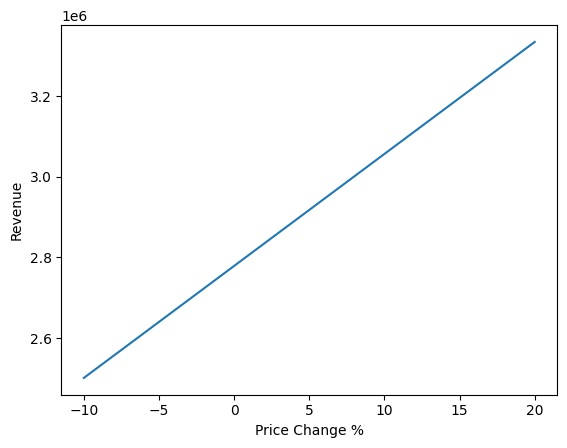

In [17]:
import matplotlib.pyplot as plt

plt.plot(
result_df[
'Price Change'
],
result_df[
'Projected Revenue'
]
)

plt.xlabel(
'Price Change %'
)

plt.ylabel(
'Revenue'
)

plt.show()